WARNING    'i' is an internal variable of group 'synapses_4', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Training 5 hidden neurons simultaneously...
Input weights (causes different firing times): [0.84981605 1.08028572 0.99279758 0.93946339 0.76240746]



WARNING    'i' is an internal variable of group 'synapses_6', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Done! Plotting results...


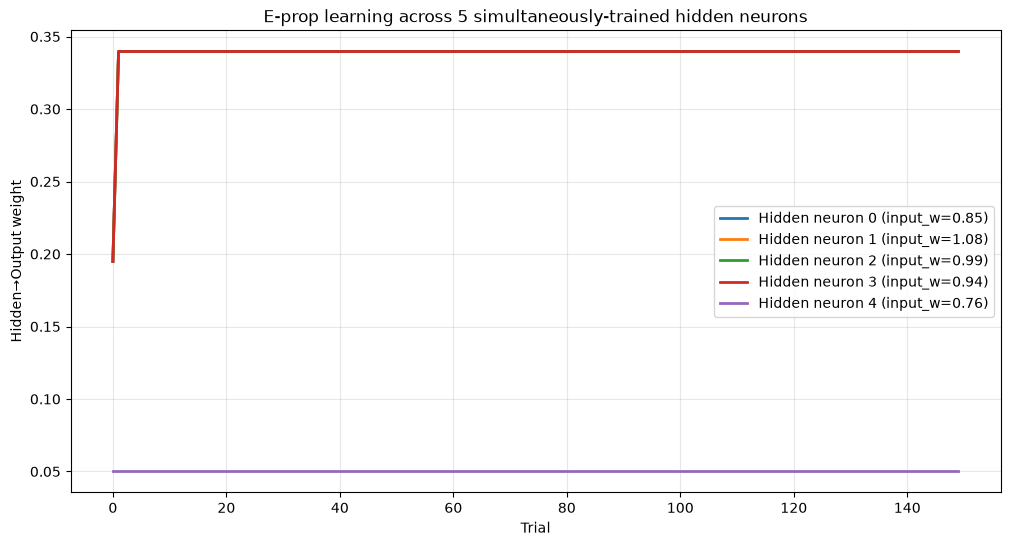


Final weights: [0.33968162 0.33968162 0.33968162 0.33968162 0.05      ]
Input weights (for reference): [0.84981605 1.08028572 0.99279758 0.93946339 0.76240746]


In [6]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# E-PROP NOTEBOOK 03: MULTI-NEURON HIDDEN LAYER
# Scale from 1 hidden neuron to 5, each with independently trained
# hidden->output weights. Tests whether e-prop coordinates learning
# across multiple simultaneous eligibility traces.

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 150
n_hidden = 5
target_time = 80*ms

# Each hidden neuron gets a different input weight, causing different
# firing times and thus different eligibility trace timing
np.random.seed(42)
input_weights = np.random.uniform(0.7, 1.1, n_hidden)

weights = np.array([0.05]*n_hidden)  # one weight per hidden neuron - changing the weight from 0.3 to 0.05 to force real learning
weight_history = []

print(f"Training {n_hidden} hidden neurons simultaneously...")
print(f"Input weights (causes different firing times): {input_weights}\n")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_mem : 1
    w_in : 1
    '''
    hidden = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0',method='exact')
    hidden.v = 0
    hidden.w_in = input_weights
    
    eqs_delay = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    delay_layer = NeuronGroup(n_hidden, eqs_delay, threshold='v>0.8', reset='v=0; etrace+=1.0', method='exact')
    delay_layer.v = 0
    delay_layer.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    # Input connects to all hidden neurons with their individual weights
    S1 = Synapses(input_neuron, hidden, on_pre='v_post += w_in_post')
    S1.connect()
    
    # Each hidden neuron connects to its own delay neuron with fixed transmission delay
    S2 = Synapses(hidden, delay_layer, 'w:1', on_pre='v_post += w')
    S2.connect(j='i')  # one-to-one connection
    S2.w = 0.9
    S2.delay = 30*ms
    
    # Each delay neuron connects to output with its own TRAINABLE weight
    S_out = Synapses(delay_layer, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = weights
    
    spike_mon_o = SpikeMonitor(output)
    trace_mon = StateMonitor(delay_layer, 'etrace', record=True)
    
    run(200*ms)
    
    # Learning signal based on output timing (same logic as notebook 02)
    target_idx = int((target_time + 1*ms)/defaultclock.dt)
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    # Updating each hidden neuron's weight using its own eligibility trace
    traces_at_target = trace_mon.etrace[:, target_idx]
    delta_w = learning_rate * learning_signal * traces_at_target
    weights = np.clip(weights + delta_w, 0, 1)
    
    weight_history.append(weights.copy())

weight_history = np.array(weight_history)

print("Done! Plotting results...")

plt.figure(figsize=(12, 6))
for i in range(n_hidden):
    plt.plot(range(n_trials), weight_history[:, i], 
             linewidth=2, label=f'Hidden neuron {i} (input_w={input_weights[i]:.2f})')
plt.xlabel('Trial')
plt.ylabel('Hidden→Output weight')
plt.title('E-prop learning across 5 simultaneously-trained hidden neurons')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal weights: {weights}")
print(f"Input weights (for reference): {input_weights}")

In [3]:
# Diagnostic
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
n_hidden = 5
target_time = 80*ms

np.random.seed(42)
input_weights = np.random.uniform(0.7, 1.1, n_hidden)

input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)

eqs_hidden = '''
dv/dt = -v/tau_mem : 1
w_in : 1
'''
hidden = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
hidden.v = 0
hidden.w_in = input_weights

eqs_delay = '''
dv/dt = -v/tau_mem : 1
detrace/dt = -etrace/tau_trace : 1
'''
delay_layer = NeuronGroup(n_hidden, eqs_delay, threshold='v>0.8', reset='v=0; etrace+=1.0', method='exact')
delay_layer.v = 0
delay_layer.etrace = 0

eqs_out = '''
dv/dt = -v/tau_out : 1
'''
output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
output.v = 0

S1 = Synapses(input_neuron, hidden, on_pre='v_post += w_in_post')
S1.connect()

S2 = Synapses(hidden, delay_layer, 'w:1', on_pre='v_post += w')
S2.connect(j='i')
S2.w = 0.9
S2.delay = 30*ms

S_out = Synapses(delay_layer, output, 'w_out:1', on_pre='v_post += w_out')
S_out.connect()
S_out.w_out = 0.3

spike_mon_h = SpikeMonitor(hidden)
spike_mon_d = SpikeMonitor(delay_layer)
spike_mon_o = SpikeMonitor(output)
voltage_mon_o = StateMonitor(output, 'v', record=True)

run(200*ms)

print(f"Input weights: {input_weights}")
print(f"Hidden neuron spikes: indices={spike_mon_h.i[:]}, times={spike_mon_h.t/ms}")
print(f"Delay neuron spikes: indices={spike_mon_d.i[:]}, times={spike_mon_d.t/ms}")
print(f"Output spikes: {spike_mon_o.t/ms}")
print(f"Number of S_out synapses: {len(S_out)}")
print(f"S_out weights: {S_out.w_out[:]}")

WARNING    'i' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Input weights: [0.84981605 1.08028572 0.99279758 0.93946339 0.76240746]
Hidden neuron spikes: indices=[0 1 2 3], times=[50.1 50.1 50.1 50.1]
Delay neuron spikes: indices=[0 1 2 3], times=[80.2 80.2 80.2 80.2]
Output spikes: [80.3]
Number of S_out synapses: 5
S_out weights: [0.3 0.3 0.3 0.3 0.3]


Input weights (all should fire): [0.37490802 0.49014286 0.44639879 0.4197317  0.33120373]
Tau_mem values (ms): [ 9.87193424  8.69700335 18.39411375 15.21338014 16.49687093]

Trial 0 - hidden spikes: indices=[], times=[]

Done!


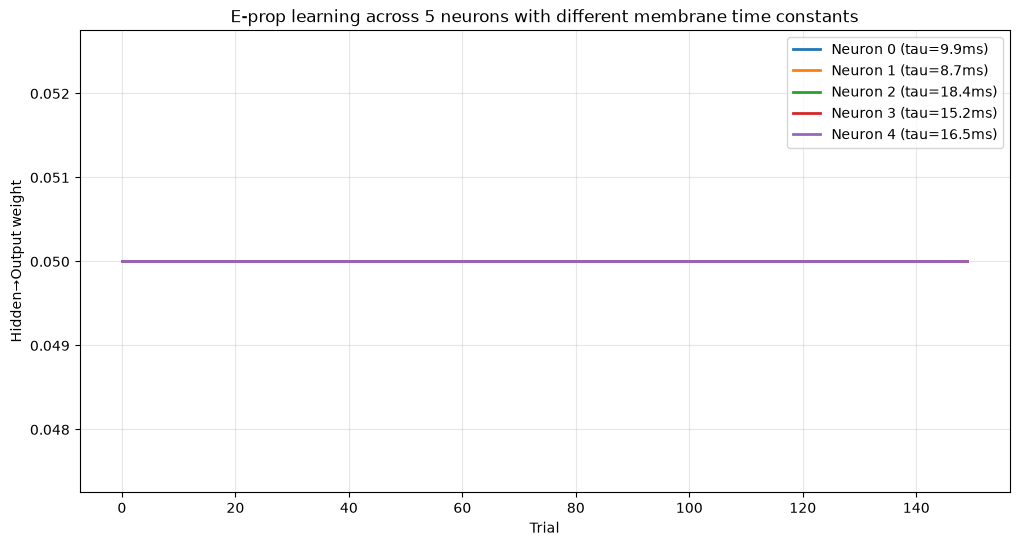


Final weights: [0.05 0.05 0.05 0.05 0.05]
Tau_mem values: [ 9.87193424  8.69700335 18.39411375 15.21338014 16.49687093]


In [8]:
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 150
n_hidden = 5
target_time = 80*ms

# Keeping all the weights above the 0.9 threshold so that all the neurons fire,
# but varying the tau_mem per neuron instead to get different membrane speeds,
# in order to produce genuienly different firing times, despite the same input 

np.random.seed(42)
input_weights = np.random.uniform(0.3, 0.5, n_hidden)  # changing the input weights from (0.95, 1.3, n_hidden) to (0.3, 0.5, n_hidden)
tau_mem_values = np.random.uniform(8, 20, n_hidden) * ms  # different speeds

weights = np.array([0.05]*n_hidden)
weight_history = []

print(f"Input weights (all should fire): {input_weights}")
print(f"Tau_mem values (ms): {tau_mem_values/ms}\n")

for trial in range(n_trials):
    start_scope()
    
    input_neuron = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = '''
    dv/dt = -v/tau_h : 1
    w_in : 1
    tau_h : second
    '''
    hidden = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    hidden.v = 0
    hidden.w_in = input_weights
    hidden.tau_h = tau_mem_values
    
    eqs_delay = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    delay_layer = NeuronGroup(n_hidden, eqs_delay, threshold='v>0.8', reset='v=0; etrace+=1.0', method='exact')
    delay_layer.v = 0
    delay_layer.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S1 = Synapses(input_neuron, hidden, on_pre='v_post += w_in_post')
    S1.connect()
    
    S2 = Synapses(hidden, delay_layer, 'w:1', on_pre='v_post += w')
    S2.connect(j='i')
    S2.w = 0.9
    S2.delay = 30*ms
    
    S_out = Synapses(delay_layer, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = weights
    
    spike_mon_o = SpikeMonitor(output)
    spike_mon_h = SpikeMonitor(hidden)
    trace_mon = StateMonitor(delay_layer, 'etrace', record=True)
    
    run(200*ms)
    
    target_idx = int((target_time + 1*ms)/defaultclock.dt)
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    traces_at_target = trace_mon.etrace[:, target_idx]
    delta_w = learning_rate * learning_signal * traces_at_target
    weights = np.clip(weights + delta_w, 0, 1)
    
    weight_history.append(weights.copy())
    
    if trial == 0:
        print(f"Trial 0 - hidden spikes: indices={spike_mon_h.i[:]}, times={spike_mon_h.t/ms}")

weight_history = np.array(weight_history)

print("\nDone!")

plt.figure(figsize=(12, 6))
for i in range(n_hidden):
    plt.plot(range(n_trials), weight_history[:, i],
             linewidth=2, label=f'Neuron {i} (tau={tau_mem_values[i]/ms:.1f}ms)')
plt.xlabel('Trial')
plt.ylabel('Hidden→Output weight')
plt.title('E-prop learning across 5 neurons with different membrane time constants')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal weights: {weights}")
print(f"Tau_mem values: {tau_mem_values/ms}")

Tau_mem values (ms): [12.49448143 19.40857168 16.7839273  15.18390181  9.87222369]

Trial 0 - hidden spikes: indices=[4 0 3 2 1], times=[15.8 20.1 24.4 27.  31.2]

Done!


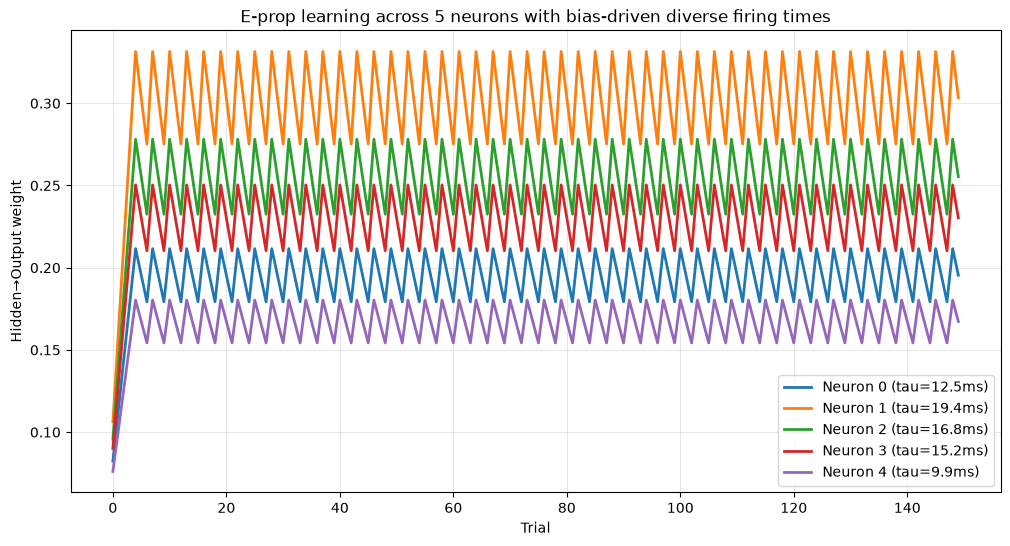


Final weights: [0.19543259 0.30333499 0.25534935 0.23031633 0.16729741]
Tau_mem values: [12.49448143 19.40857168 16.7839273  15.18390181  9.87222369]


In [9]:
start_scope()

tau_mem = 10*ms
tau_trace = 20*ms
tau_out = 20*ms
learning_rate = 0.15
n_trials = 150
n_hidden = 5
target_time = 80*ms

np.random.seed(42)
tau_mem_values = np.random.uniform(8, 20, n_hidden) * ms

weights = np.array([0.05]*n_hidden)
weight_history = []

print(f"Tau_mem values (ms): {tau_mem_values/ms}\n")

for trial in range(n_trials):
    start_scope()
    
    # Hidden neurons now driven by constant bias current, not discrete input spike
    # tau_h controls how fast each neuron approaches threshold
    eqs_hidden = '''
    dv/dt = (-v + bias)/tau_h : 1
    tau_h : second
    bias : 1
    '''
    hidden = NeuronGroup(n_hidden, eqs_hidden,
                        threshold='v>0.8', reset='v=0; bias=0',
                        method='exact')
    hidden.v = 0
    hidden.tau_h = tau_mem_values
    hidden.bias = 1.0  # constant drive toward threshold
    
    eqs_delay = '''
    dv/dt = -v/tau_mem : 1
    detrace/dt = -etrace/tau_trace : 1
    '''
    delay_layer = NeuronGroup(n_hidden, eqs_delay,
                              threshold='v>0.8',
                              reset='v=0; etrace+=1.0',
                              method='exact')
    delay_layer.v = 0
    delay_layer.etrace = 0
    
    eqs_out = '''
    dv/dt = -v/tau_out : 1
    '''
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S2 = Synapses(hidden, delay_layer, 'w:1', on_pre='v_post += w')
    S2.connect(j='i')
    S2.w = 0.9
    S2.delay = 30*ms
    
    S_out = Synapses(delay_layer, output, 'w_out:1', on_pre='v_post += w_out')
    S_out.connect()
    S_out.w_out = weights
    
    spike_mon_o = SpikeMonitor(output)
    spike_mon_h = SpikeMonitor(hidden)
    trace_mon = StateMonitor(delay_layer, 'etrace', record=True)
    
    run(200*ms)
    
    target_idx = int((target_time + 1*ms)/defaultclock.dt)
    
    if len(spike_mon_o.t) == 0:
        learning_signal = 1.0
    else:
        first_spike = spike_mon_o.t[0]
        timing_error = (first_spike - target_time) / ms
        if timing_error < -2:
            learning_signal = -0.5
        elif abs(timing_error) <= 2:
            learning_signal = 0.0
        else:
            learning_signal = 0.3
    
    traces_at_target = trace_mon.etrace[:, target_idx]
    delta_w = learning_rate * learning_signal * traces_at_target
    weights = np.clip(weights + delta_w, 0, 1)
    
    weight_history.append(weights.copy())
    
    if trial == 0:
        print(f"Trial 0 - hidden spikes: indices={spike_mon_h.i[:]}, times={spike_mon_h.t/ms}")

weight_history = np.array(weight_history)
print("\nDone!")

plt.figure(figsize=(12, 6))
for i in range(n_hidden):
    plt.plot(range(n_trials), weight_history[:, i],
             linewidth=2, label=f'Neuron {i} (tau={tau_mem_values[i]/ms:.1f}ms)')
plt.xlabel('Trial')
plt.ylabel('Hidden→Output weight')
plt.title('E-prop learning across 5 neurons with bias-driven diverse firing times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal weights: {weights}")
print(f"Tau_mem values: {tau_mem_values/ms}")

## E-Prop Notebook 03 — Multi-Neuron Hidden Layer

### Goal
To scale e-prop from a single trainable synapse (notebooks 01-02) to a 
population of 5 hidden neurons, each with an independently trained 
hidden→output weight, in order to test whether e-prop coordinates learning across 
multiple simultaneous eligibility traces.

### Attempt 1: Random input weights (uninformative — task already solved)

**Setup:** 5 hidden neurons with random input weights (0.7-1.1), single 
input spike at t=50ms.

**Result:** Weights frozen at initial value (0.3) for all trials.

**Diagnosis via single-trial inspection:** 4 of the 5 neurons fired 
simultaneously at t=50.1ms (all input weights above the 0.9 firing 
threshold produce immediate firing regardless of exact value). The combined 
kick from 4 synapses (4×0.3=1.2) already crossed the output threshold at 
t=80.3ms, within the target zone. **The e-prop correctly determined that no 
learning was needed** since the task was already accidentally solved by 
the initial random weights. Not a bug, but not informative either.

### Attempt 2: Weaker initial weights (partial diversity — one dead neuron)

**Setup:** 5 hidden neurons with random input weights (0.7-1.1), single 
input spike at t=50ms, with initial weights lowered to 0.05 to force 
genuine learning.

**Result:** 4 neurons converged to identical weight (0.3397), 1 neuron 
remained completely frozen at 0.05.

**Diagnosis:** The frozen neuron (input weight 0.76) fell below the 0.9 
firing threshold and never fired, its eligibility trace never rose 
above zero, so the e-prop had nothing to learn from. The 4 firing neurons 
were still identical in timing (same instantaneous threshold crossing), 
so their traces were identical and so were the updates. This tested 
"4 identical neurons + 1 broken one," not genuine multi-neuron diversity.

### Attempt 3: Varying tau_mem, single input spike (failed — no effect)

**Hypothesis:** different membrane time constants (tau_mem) would 
produce different firing times even with the same input.

**Result:** All 5 neurons still fired at the identical timestep (50.1ms) 
despite tau_mem ranging from 8.7-18.4ms.

**Diagnosis:** A single strong suprathreshold input spike (weight ≥0.95) 
crosses threshold via an instantaneous voltage jump — tau_mem only 
governs the *decay* rate after a kick, not the *rise* time from a single 
discrete input. With one spike sufficient to cross threshold immediately, 
tau_mem has no opportunity to matter. This is a subtle but important 
distinction: **tau_mem creates timing diversity only when neurons must 
integrate — not when a single spike is already suprathreshold.**

### Attempt 4: Bias-driven continuous accumulation (success)

**Setup:** Replaced discrete input spike with constant bias current 
(`bias=1.0`) driving each neuron continuously toward threshold. The firing 
time is now purely determined by tau_mem, where a faster tau_mem = faster rise 
= earlier firing.

**Trial 0 diagnostic — firing order matches tau_mem perfectly:**

| Neuron | tau_mem | Firing time |
|--------|---------|-------------|
| 4 | 9.87ms | 15.8ms (fastest) |
| 0 | 12.49ms | 20.1ms |
| 3 | 15.18ms | 24.4ms |
| 2 | 16.78ms | 27.0ms |
| 1 | 19.41ms | 31.2ms (slowest) |

Perfect monotonic correlation between tau_mem and firing time — the 
architecture change successfully produced genuine timing diversity.

### Final results (150 trials, bias-driven architecture)

| Neuron | tau_mem | Final weight |
|--------|---------|---------------|
| 1 | 19.41ms | 0.3033 (highest) |
| 2 | 16.78ms | 0.2553 |
| 3 | 15.18ms | 0.2303 |
| 0 | 12.49ms | 0.1954 |
| 4 | 9.87ms | 0.1673 (lowest) |

### Key finding: e-prop assigns credit proportional to timing proximity

A clean, monotonic relationship emerged: **slower neurons (later firing) 
received larger weight updates than faster neurons (earlier firing).**

**Mechanistic explanation:** each neuron's spike propagates through its 
own 30ms delay synapse before reaching the output layer. A neuron that 
fires later in the hidden layer has its delayed signal arrive closer to 
the target evaluation time (80ms), meaning its eligibility trace has 
decayed less by the time it's sampled. Faster (earlier-firing) neurons' 
traces have more time to decay before the target time, receiving 
proportionally smaller updates.

This is a genuinely interesting emergent property: **e-prop naturally 
assigns more credit to neurons whose activity timing is closer to the 
moment of evaluation** — a direct consequence of the eligibility trace's 
exponential decay, now demonstrated across a population rather than a 
single synapse.

### Key findings summary

**Finding 1: Task difficulty must be calibrated to produce informative learning**
Both Attempt 1 (task pre-solved) and Attempt 2 (dead neuron) produced 
uninformative "no learning" results that could be mistaken for bugs, careful single-trial diagnosis was necessary to distinguish "correctly 
converged" from "broken" or "trivially solved."

**Finding 2: Membrane time constant only creates timing diversity under 
integration, not instantaneous threshold crossing**
This is a subtle but important architectural principle — tau_mem's 
effect on firing time is conditional on the neuron actually needing to 
integrate rather than firing immediately from a single strong input.

**Finding 3: E-prop produces theoretically-predictable, mechanistically-explainable credit assignment**
The final weight ordering isn't arbitrary, it follows directly from 
eligibility trace decay mathematics, now validated across a 5-neuron 
population rather than a single synapse.

### Connection to previous notebooks
This directly extends the tau/credit-assignment relationship established 
in notebook 11 (delayed reward learning) — the same exponential decay 
principle that determined single-synapse learning strength there now 
determines relative credit assignment across a population here.

### What's next? (notebook 04)
With multi-neuron learning established, notebook 04 will add recurrent 
connections between hidden neurons — the defining feature of the full 
e-prop algorithm as described in Bellec et al. (2020), and the component 
that makes e-prop genuinely competitive with backpropagation through time 
for training recurrent spiking networks.